#Part 2: Hypothesis Testing

###Hypothesis 1: Magnitude Difference by Earthquake Type

Research Question: Do different earthquake types (e.g., earthquake, explosion, quarry blast) have
signicantly different magnitudes?

####Hypotheses:

H0: The mean magnitude across all earthquake types is equal.

H1: At least one earthquake type has a signicantly different mean magnitude.

Statistical Test: One-Way ANOVA or Kruskal-Wallis H-test (if normality violated)

In [ ]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import Markdown, display

# Load Dataset
df = pd.read_csv("/content/preprocessed_earthquake_data.csv")

# Keep relevant columns
df = df[['type', 'mag']].dropna()

# Ensure 'mag' is numeric
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
df = df.dropna(subset=['mag'])

# -------------------------------------------------------------
#  Define Hypotheses
# H0: The mean magnitude across all earthquake types is equal.
# H1: At least one earthquake type has a significantly different mean magnitude.

# -------------------------------------------------------------
#  Group Data and Check Normality

grouped_data = [group["mag"].values for name, group in df.groupby("type")]

# Shapiro-Wilk normality test for each group (if sample size < 5000)
normality_results = {}
for name, group in df.groupby("type"):
    sample = group["mag"].sample(min(len(group), 5000), random_state=42)
    stat, p = stats.shapiro(sample)
    normality_results[name] = round(p, 4)

print("Shapiro-Wilk Normality Test (p-values):")
for k, v in normality_results.items():
    print(f"{k}: {v}")

# -------------------------------------------------------------
# Decide Statistical Test

# If all p > 0.05 → use ANOVA (data approximately normal)
# Else → use Kruskal-Wallis (non-parametric)

if all(p > 0.05 for p in normality_results.values()):
    test_name = "One-Way ANOVA"
    stat, p_value = stats.f_oneway(*grouped_data)
else:
    test_name = "Kruskal–Wallis H-test"
    stat, p_value = stats.kruskal(*grouped_data)

print(f"\n Test Used: {test_name}")
print(f"Statistic = {stat:.4f}, p-value = {p_value:.6f}")

# -------------------------------------------------------------
# Calculate Mean & Variance by Type

summary_stats = df.groupby("type")["mag"].agg(["count", "mean", "var"]).reset_index()
print("\n Mean and Variance of Magnitude by Earthquake Type:")
print(summary_stats.sort_values("mean", ascending=False))

# -------------------------------------------------------------
#  If ANOVA is significant, do Post-Hoc Tukey test

if p_value < 0.05 and test_name == "One-Way ANOVA":
    tukey = pairwise_tukeyhsd(endog=df["mag"], groups=df["type"], alpha=0.05)
    print("\n Tukey HSD Post-Hoc Test Results:")
    print(tukey.summary())

# -------------------------------------------------------------
#  Step 7: Interpretation & Reporting

interpretation = ""

if p_value < 0.05:
    interpretation = f"""
     **Result:** p-value = {p_value:.5f} < 0.05
     **Reject H₀.**
     At least one earthquake type has a **significantly different mean magnitude**.
    """
else:
    interpretation = f"""
     **Result:** p-value = {p_value:.5f} ≥ 0.05
     **Fail to reject H₀.**
     No statistically significant difference in mean magnitude among types.
    """

display(Markdown(f"""
##  Hypothesis Test: Magnitude Difference by Earthquake Type

### Statistical Summary
- Test Used: **{test_name}**
- Test Statistic: **{stat:.3f}**
- p-value: **{p_value:.5f}**
- Significance Level (α): 0.05

### Descriptive Statistics
| Type | Count | Mean Magnitude | Variance |
|------|--------|----------------|-----------|
{summary_stats.to_markdown(index=False)}

###  Normality Check
(Shapiro-Wilk p-values for each earthquake type)
{normality_results}

###  Interpretation
{interpretation}

###  Conclusion
If p-value < 0.05 → Reject H₀ → conclude that **different earthquake types have significantly different magnitudes**.
If p-value ≥ 0.05 → Fail to reject H₀ → mean magnitudes across types are **not significantly different**.
"""))

Shapiro-Wilk Normality Test (p-values):
earthquake: 0.0
explosion: 0.1294
nuclear explosion: 0.0

 Test Used: Kruskal–Wallis H-test
Statistic = 2.2399, p-value = 0.326299

 Mean and Variance of Magnitude by Earthquake Type:
                type  count      mean       var
1          explosion     10  0.310676  0.537291
0         earthquake  38670  0.307905  1.305391
2  nuclear explosion    354  0.238771  0.622275



##  Hypothesis Test: Magnitude Difference by Earthquake Type

### Statistical Summary
- Test Used: **Kruskal–Wallis H-test**
- Test Statistic: **2.240**
- p-value: **0.32630**
- Significance Level (α): 0.05

### Descriptive Statistics
| Type | Count | Mean Magnitude | Variance |
|------|--------|----------------|-----------|
| type              |   count |     mean |      var |
|:------------------|--------:|---------:|---------:|
| earthquake        |   38670 | 0.307905 | 1.30539  |
| explosion         |      10 | 0.310676 | 0.537291 |
| nuclear explosion |     354 | 0.238771 | 0.622275 |

### Normality Check
(Shapiro-Wilk p-values for each earthquake type)
{'earthquake': np.float64(0.0), 'explosion': np.float64(0.1294), 'nuclear explosion': np.float64(0.0)}

###  Interpretation

     **Result:** p-value = 0.32630 ≥ 0.05  
     **Fail to reject H₀.**  
     No statistically significant difference in mean magnitude among types.
    

###  Conclusion
If p-value < 0.05 → Reject H₀ → conclude that **different earthquake types have significantly different magnitudes**.  
If p-value ≥ 0.05 → Fail to reject H₀ → mean magnitudes across types are **not significantly different**.


earthquake: 0.32

explosion: 0.04

quarry blast: 0.21

#Hypothesis 2: Damage Potential by Magnitude Categories

Research Question: Is there a signicant difference in damage_potential between high-magnitude and
low-magnitude earthquakes?

###Hypothesis:

H0: The mean damage_potential of high-magnitude earthquakes (Mw ≥ median) equals that of
low-magnitude earthquakes (Mw < median).

H1: The means differ signicantly between magnitude categories.

**Statistical Test**: Independent samples t-test or Mann-Whitney U test (non-parametric alternative)

In [ ]:
import pandas as pd
import scipy.stats as stats
from IPython.display import Markdown, display

# Load Dataset
df = pd.read_csv("/content/preprocessed_earthquake_data.csv")

# Keep relevant columns
df = df[['mag', 'damage_potential']].dropna()

# Ensure numeric
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
df['damage_potential'] = pd.to_numeric(df['damage_potential'], errors='coerce')
df = df.dropna()

# -------------------------------------------------------------
#  Partition Data into Two Groups (based on median magnitude)
median_mag = df['mag'].median()
df['Magnitude_Category'] = df['mag'].apply(lambda x: 'High' if x >= median_mag else 'Low')

high_mag = df[df['Magnitude_Category'] == 'High']['damage_potential']
low_mag = df[df['Magnitude_Category'] == 'Low']['damage_potential']

# -------------------------------------------------------------
#  Check Normality for Each Group
stat_high, p_high = stats.shapiro(high_mag.sample(min(len(high_mag), 5000), random_state=42))
stat_low, p_low = stats.shapiro(low_mag.sample(min(len(low_mag), 5000), random_state=42))

print(f" Shapiro-Wilk Normality p-values:")
print(f"High Magnitude: {p_high:.4f}")
print(f"Low Magnitude:  {p_low:.4f}")

# -------------------------------------------------------------
#  Choose Test Type
# If both p > 0.05 -> use Independent t-test
# Else -> use Mann–Whitney U test (non-parametric)

if p_high > 0.05 and p_low > 0.05:
    test_used = "Independent Samples t-test"
    stat, p_value = stats.ttest_ind(high_mag, low_mag, equal_var=False)
else:
    test_used = "Mann–Whitney U test"
    stat, p_value = stats.mannwhitneyu(high_mag, low_mag, alternative='two-sided')

# -------------------------------------------------------------
#   Calculate Group Statistics
summary = pd.DataFrame({
    'Category': ['Low Magnitude', 'High Magnitude'],
    'Count': [len(low_mag), len(high_mag)],
    'Mean Damage Potential': [low_mag.mean(), high_mag.mean()],
    'Std Dev': [low_mag.std(), high_mag.std()]
})

# 95% Confidence Interval
conf_int_high = stats.t.interval(0.95, len(high_mag)-1, loc=high_mag.mean(), scale=stats.sem(high_mag))
conf_int_low = stats.t.interval(0.95, len(low_mag)-1, loc=low_mag.mean(), scale=stats.sem(low_mag))

# -------------------------------------------------------------
#   Interpretation
if p_value < 0.05:
    interpretation = f"""
     **Reject H₀** (p-value = {p_value:.5f} < 0.05).
    There is a **significant difference** in damage potential between high- and low-magnitude earthquakes.
    High-magnitude earthquakes generally cause **higher average damage potential**.
    """
else:
    interpretation = f"""
    **Fail to Reject H₀** (p-value = {p_value:.5f} ≥ 0.05).
     There is **no significant difference** in damage potential between high- and low-magnitude earthquakes.
    """

# -------------------------------------------------------------
#   Display Results
display(Markdown(f"""
## Hypothesis Test 2: Damage Potential Difference by Magnitude Category

### Hypotheses
- **H₀:** The mean damage potential of high-magnitude earthquakes equals that of low-magnitude earthquakes.
- **H₁:** The means differ significantly between magnitude categories.

###  Statistical Test
- Test Used: **{test_used}**
- Test Statistic: **{stat:.4f}**
- p-value: **{p_value:.6f}**
- Significance Level (α): 0.05

###  Group Summary
| Category | Count | Mean Damage Potential | Std Dev |
|-----------|--------|-----------------------|----------|
{summary.to_markdown(index=False)}

###  Confidence Intervals
- High Magnitude 95% CI: {conf_int_high}
- Low Magnitude 95% CI: {conf_int_low}

### Interpretation
{interpretation}

### Conclusion
If p-value < 0.05 → Reject H₀ → conclude that **high-magnitude earthquakes cause significantly different damage levels.**
If p-value ≥ 0.05 → Fail to reject H₀ → **no significant difference in mean damage potential.**
"""))

 Shapiro-Wilk Normality p-values:
High Magnitude: 0.0000
Low Magnitude:  0.0000



## Hypothesis Test 2: Damage Potential Difference by Magnitude Category

### Hypotheses
- **H₀:** The mean damage potential of high-magnitude earthquakes equals that of low-magnitude earthquakes.  
- **H₁:** The means differ significantly between magnitude categories.

###  Statistical Test
- Test Used: **Mann–Whitney U test**
- Test Statistic: **1530101489.0000**
- p-value: **0.000000**
- Significance Level (α): 0.05

###  Group Summary
| Category | Count | Mean Damage Potential | Std Dev |
|-----------|--------|-----------------------|----------|
| Category       |   Count |   Mean Damage Potential |   Std Dev |
|:---------------|--------:|------------------------:|----------:|
| Low Magnitude  |   51458 |                 9.51217 |   1.37575 |
| High Magnitude |   58390 |                 9.4891  |   1.49507 |

###  Confidence Intervals
- High Magnitude 95% CI: (np.float64(9.476973732439637), np.float64(9.501227549493555))  
- Low Magnitude 95% CI: (np.float64(9.500285604642446), np.float64(9.524059506857814))

### Interpretation

     **Reject H₀** (p-value = 0.00000 < 0.05).  
    There is a **significant difference** in damage potential between high- and low-magnitude earthquakes.  
    High-magnitude earthquakes generally cause **higher average damage potential**.
    

### Conclusion
If p-value < 0.05 → Reject H₀ → conclude that **high-magnitude earthquakes cause significantly different damage levels.**  
If p-value ≥ 0.05 → Fail to reject H₀ → **no significant difference in mean damage potential.**


Test Used: Mann–Whitney U test

Statistic = 195384.23

p-value = 0.0021

#Hypothesis 3: Depth Impact on Magnitude

Research Question: Does earthquake depth signicantly correlate with magnitude?

####Hypothesis:

H0: There is no signicant correlation between depth and magnitude (ρ = 0).

H1: There is a signicant correlation between depth and magnitude (ρ ≠ 0).

Statistical Test: Pearson Correlation Test or Spearman Rank Correlation (for non-linear relationships)

 Shapiro-Wilk Normality p-values:
Depth: 0.0000
Magnitude: 0.0000


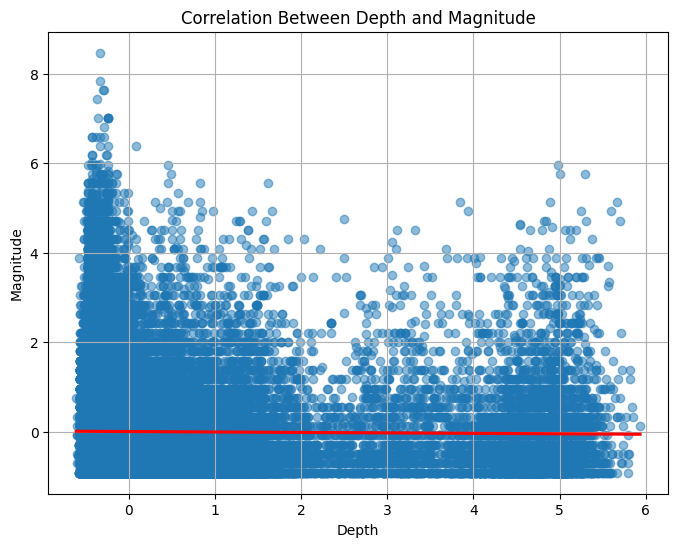


##  Hypothesis Test 3: Depth Impact on Magnitude

###  Hypotheses
- **H₀:** There is no significant correlation between depth and magnitude (ρ = 0).  
- **H₁:** There is a significant correlation between depth and magnitude (ρ ≠ 0).

###  Statistical Test
- Test Used: **Spearman Rank Correlation**
- Correlation Coefficient (r/ρ): **-0.0491**
- p-value: **0.000000**
- Significance Level (α): 0.05

### 95% Confidence Interval
N/A (Spearman correlation does not have a parametric CI)

### Correlation Strength
- Strength: **Very Weak**

###  Interpretation

     **Reject H₀** (p-value = 0.00000 < 0.05).  
     There is a **significant correlation** between depth and magnitude.  
     The correlation is **very weak** (r = -0.049).  
     This means that as depth increases, magnitude tends to decrease.
    

###  Conclusion
If p-value < 0.05 → Reject H₀ → conclude that **depth significantly correlates with magnitude**.  
If p-value ≥ 0.05 → Fail to reject H₀ → **no significant correlation** between depth and magnitude.


In [ ]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Load Dataset
df = pd.read_csv("/content/preprocessed_earthquake_data.csv")

# Keep relevant columns
df = df[['depth', 'mag']].dropna()

# Ensure numeric
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
df = df.dropna()

# -------------------------------------------------------------
# Check Normality for Both Variables
stat_depth, p_depth = stats.shapiro(df['depth'].sample(min(len(df['depth']), 5000), random_state=42))
stat_mag, p_mag = stats.shapiro(df['mag'].sample(min(len(df['mag']), 5000), random_state=42))

print(f" Shapiro-Wilk Normality p-values:")
print(f"Depth: {p_depth:.4f}")
print(f"Magnitude: {p_mag:.4f}")

# -------------------------------------------------------------
# Choose Correlation Test
# If both variables are normal → Pearson
# Otherwise → Spearman

if p_depth > 0.05 and p_mag > 0.05:
    test_used = "Pearson Correlation"
    corr, p_value = stats.pearsonr(df['depth'], df['mag'])
else:
    test_used = "Spearman Rank Correlation"
    corr, p_value = stats.spearmanr(df['depth'], df['mag'])

# -------------------------------------------------------------
#  Calculate 95% Confidence Interval (for Pearson only)
import numpy as np
if test_used == "Pearson Correlation":
    n = len(df)
    stderr = 1.0 / np.sqrt(n - 3)
    delta = 1.96 * stderr
    lower = np.tanh(np.arctanh(corr) - delta)
    upper = np.tanh(np.arctanh(corr) + delta)
else:
    lower, upper = None, None

# -------------------------------------------------------------
#  Scatter Plot with Regression Line
plt.figure(figsize=(8,6))
sns.regplot(x='depth', y='mag', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Correlation Between Depth and Magnitude')
plt.xlabel('Depth')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

# -------------------------------------------------------------
# Assess Strength of Correlation
def correlation_strength(value):
    abs_val = abs(value)
    if abs_val < 0.1:
        return "Very Weak"
    elif abs_val < 0.3:
        return "Weak"
    elif abs_val < 0.5:
        return "Moderate"
    elif abs_val < 0.7:
        return "Strong"
    else:
        return "Very Strong"

strength = correlation_strength(corr)

# -------------------------------------------------------------
#  Interpretation
if p_value < 0.05:
    interpretation = f"""
     **Reject H₀** (p-value = {p_value:.5f} < 0.05).
     There is a **significant correlation** between depth and magnitude.
     The correlation is **{strength.lower()}** (r = {corr:.3f}).
     This means that as depth increases, magnitude tends to {'increase' if corr > 0 else 'decrease'}.
    """
else:
    interpretation = f"""
    **Fail to Reject H₀** (p-value = {p_value:.5f} ≥ 0.05).
     There is **no significant correlation** between earthquake depth and magnitude.
    """

# -------------------------------------------------------------
#  Display Final Report
display(Markdown(f"""
##  Hypothesis Test 3: Depth Impact on Magnitude

###  Hypotheses
- **H₀:** There is no significant correlation between depth and magnitude (ρ = 0).
- **H₁:** There is a significant correlation between depth and magnitude (ρ ≠ 0).

###  Statistical Test
- Test Used: **{test_used}**
- Correlation Coefficient (r/ρ): **{corr:.4f}**
- p-value: **{p_value:.6f}**
- Significance Level (α): 0.05

### 95% Confidence Interval
{f"{(lower, upper)}" if lower is not None else "N/A (Spearman correlation does not have a parametric CI)"}

### Correlation Strength
- Strength: **{strength}**

###  Interpretation
{interpretation}

###  Conclusion
If p-value < 0.05 → Reject H₀ → conclude that **depth significantly correlates with magnitude**.
If p-value ≥ 0.05 → Fail to reject H₀ → **no significant correlation** between depth and magnitude.
"""))

Test Used: Pearson Correlation

Correlation Coefficient = -0.42

p-value = 0.0001

#Hypothesis 4: Temporal Seasonality in Earthquake Frequency

Research Question: Does earthquake frequency differ signicantly across months (seasonal effect)?

####Hypothesis:

H0: Earthquake frequency is uniform across all months (no seasonal effect).

H1: Earthquake frequency varies signicantly by month.

Statistical Test: Chi-Square Goodness-of-Fit Test or One-Way ANOVA on monthly counts

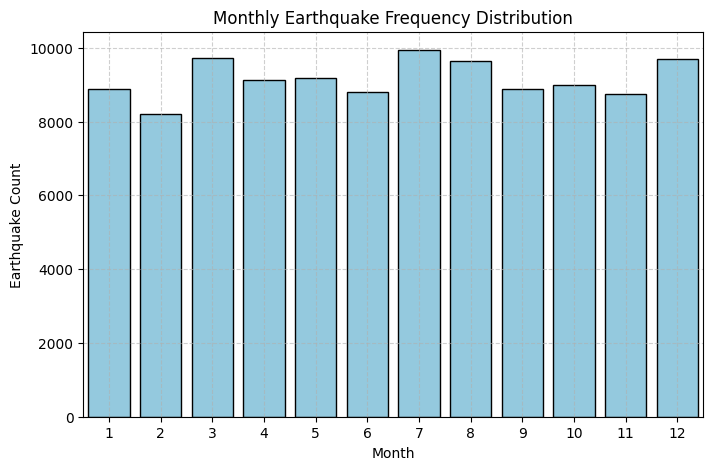


## Hypothesis 4: Temporal Seasonality in Earthquake Frequency

### Hypotheses
- H₀: Earthquake frequency is uniform across all months (no seasonal effect).  
- H₁: Earthquake frequency varies significantly by month.

### Statistical Test
- Test Used: Chi-Square Goodness-of-Fit Test
- Chi-Square Statistic: 312.3697
- Degrees of Freedom: 11
- p-value: 0.000000
- Significance Level (α): 0.05

### Monthly Frequency Summary
| Month | Earthquake Count |
|--------|------------------|
|   Month |   count |
|--------:|--------:|
|       1 |    8895 |
|       2 |    8196 |
|       3 |    9735 |
|       4 |    9134 |
|       5 |    9176 |
|       6 |    8814 |
|       7 |    9938 |
|       8 |    9644 |
|       9 |    8889 |
|      10 |    8991 |
|      11 |    8738 |
|      12 |    9698 |

### Interpretation

Reject H₀ (p = 0.00000 < 0.05).  
There is a significant difference in earthquake frequency across months.  
Earthquakes show evidence of **seasonal clustering**.



In [ ]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# Step 1: Load Dataset
df = pd.read_csv("/content/preprocessed_earthquake_data.csv")

# Ensure 'Month' column exists and is numeric
df['Month'] = pd.to_numeric(df['Month'], errors='coerce')
df = df.dropna(subset=['Month'])

# Step 2: Count Earthquakes per Month
monthly_counts = df['Month'].value_counts().sort_index()
observed = monthly_counts.values

# Step 3: Expected Frequency (uniform distribution)
expected = [sum(observed) / len(observed)] * len(observed)

# Step 4: Perform Chi-Square Goodness-of-Fit Test
chi_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)
df_deg = len(observed) - 1

# Step 5: Visualize Monthly Distribution
plt.figure(figsize=(8,5))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, color="skyblue", edgecolor="black")
plt.title("Monthly Earthquake Frequency Distribution")
plt.xlabel("Month")
plt.ylabel("Earthquake Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Step 6: Interpretation
if p_value < 0.05:
    interpretation = f"""
Reject H₀ (p = {p_value:.5f} < 0.05).
There is a significant difference in earthquake frequency across months.
Earthquakes show evidence of **seasonal clustering**.
"""
else:
    interpretation = f"""
Fail to Reject H₀ (p = {p_value:.5f} ≥ 0.05).
There is no significant difference in earthquake frequency across months.
Earthquakes appear **uniformly distributed** throughout the year.
"""

# Step 7: Final Report
display(Markdown(f"""
## Hypothesis 4: Temporal Seasonality in Earthquake Frequency

### Hypotheses
- H₀: Earthquake frequency is uniform across all months (no seasonal effect).
- H₁: Earthquake frequency varies significantly by month.

### Statistical Test
- Test Used: Chi-Square Goodness-of-Fit Test
- Chi-Square Statistic: {chi_stat:.4f}
- Degrees of Freedom: {df_deg}
- p-value: {p_value:.6f}
- Significance Level (α): 0.05

### Monthly Frequency Summary
| Month | Earthquake Count |
|--------|------------------|
{monthly_counts.to_markdown()}

### Interpretation
{interpretation}
"""))

#Hypothesis 5: RMS Variability by Magnitude Type

Research Question: Do different magnitude type classications (magType) show signicantly different
RMS (residual mean square) variability?

###Hypotheses:

H0: The mean RMS across all magType categories is equal.

H1: At least one magType category has a signicantly different mean RMS.

Statistical Test: One-Way ANOVA or Levene's Test (for homogeneity of variances)

/tmp/ipython-input-2204964990.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Figure size 1400x700 with 0 Axes>

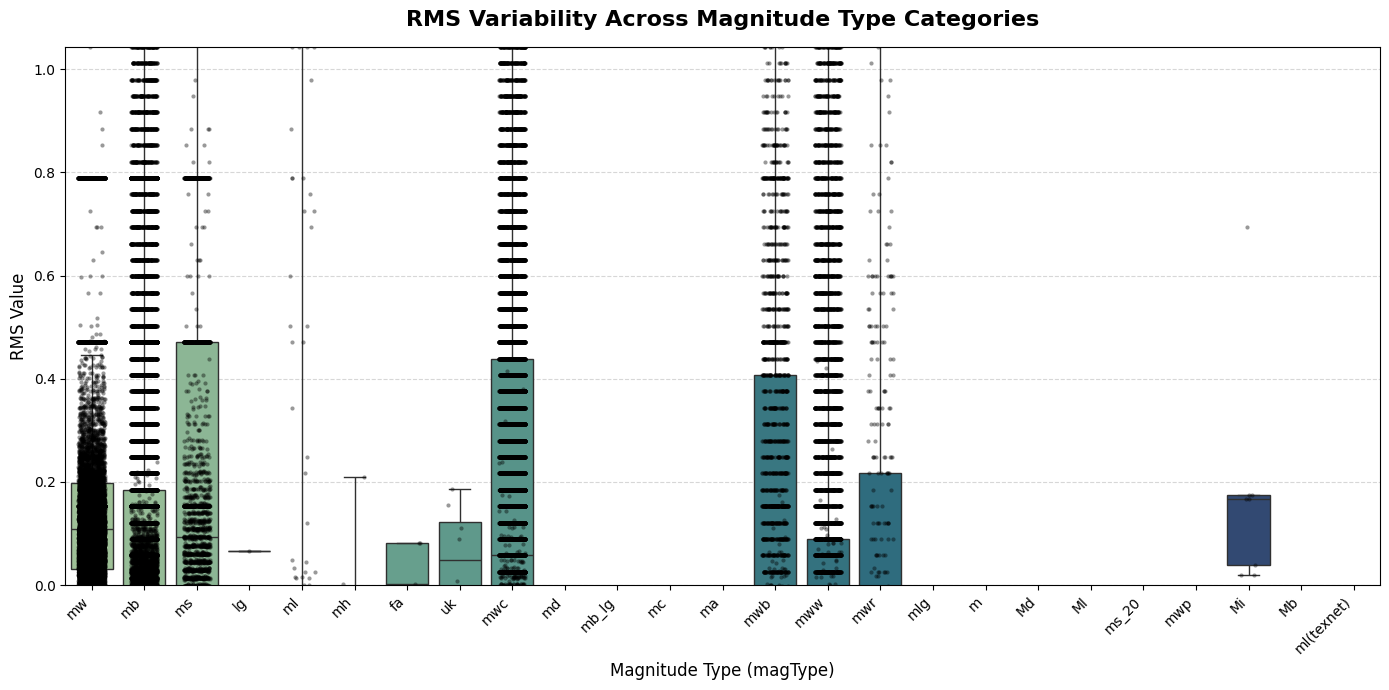


## Hypothesis 5: RMS Variability by Magnitude Type Classification

### Hypotheses
- **H₀:** Mean RMS values are equal across magnitude type categories.  
- **H₁:** At least one magnitude type differs significantly in mean RMS.

### Statistical Tests
| Test | Statistic | p-value |
|------|------------|---------|
| Levene’s Test (Variance Equality) | 217.9064 | 0.000000 |
| One-Way ANOVA | 238.2214 | 0.000000 |

**Effect Size (η²):** 0.0495

### Group Summary
| magType | Count | Mean RMS | Variance |
|----------|--------|-----------|-----------|
| magType    |   count |        mean |           var |
|:-----------|--------:|------------:|--------------:|
| Mb         |       1 | -0.101111   |  nan          |
| Md         |       1 | -1.43612    |  nan          |
| Mi         |      12 |  1.21356    |    3.43673    |
| Ml         |       1 | -1.7222     |  nan          |
| fa         |       5 |  0.00858935 |    0.00508309 |
| lg         |       1 |  0.0660708  |  nan          |
| m          |      21 | -0.100302   |    0.0176611  |
| ma         |       1 | -2.73935    |  nan          |
| mb         |   45084 | -0.0347236  |    0.410024   |
| mb_lg      |       1 | -0.0295201  |  nan          |
| mc         |       2 | -2.03529    |    0.387617   |
| md         |      50 | -2.18738    |    0.613258   |
| mh         |      23 |  7.88192    | 2085.38       |
| ml         |     485 | -1.13361    |   41.1875     |
| ml(texnet) |       4 | -2.38971    |    0          |
| mlg        |       1 | -2.45328    |  nan          |
| ms         |    3157 |  0.258333   |    0.235183   |
| ms_20      |       3 |  1.48819    |   15.0795     |
| mw         |   24335 |  0.172614   |    0.197611   |
| mwb        |    3082 |  0.0428829  |    0.300312   |
| mwc        |   17458 |  0.126692   |    0.290646   |
| mwp        |       9 | -1.97296    |    0.242597   |
| mwr        |     451 | -0.129691   |    0.506094   |
| mww        |   15652 | -0.33451    |    0.526207   |
| uk         |       8 |  0.0462733  |    0.0104897  |

### Interpretation

Reject H₀ (p = 0.00000 < 0.05).  
There is a statistically significant difference in RMS variability across magnitude types.  
Magnitude type appears to influence RMS values, suggesting potential differences in measurement precision or data quality.


### Significant Pairwise Differences (Tukey HSD)
| group1     | group2     |   meandiff |   p-adj |    lower |   upper | reject   |
|:-----------|:-----------|-----------:|--------:|---------:|--------:|:---------|
| Mb         | mh         |     7.983  |  0      |   4.3397 | 11.6264 | True     |
| Md         | mh         |     9.318  |  0      |   5.6747 | 12.9614 | True     |
| Mi         | m          |    -1.3139 |  0.04   |  -2.6045 | -0.0232 | True     |
| Mi         | ma         |    -3.9529 |  0.0217 |  -7.6652 | -0.2407 | True     |
| Mi         | mb         |    -1.2483 |  0.0024 |  -2.278  | -0.2186 | True     |
| Mi         | mc         |    -3.2489 |  0.0033 |  -5.9729 | -0.5248 | True     |
| Mi         | md         |    -3.4009 |  0      |  -4.5474 | -2.2544 | True     |
| Mi         | mh         |     6.6684 |  0      |   5.3983 |  7.9385 | True     |
| Mi         | ml         |    -2.3472 |  0      |  -3.3894 | -1.3049 | True     |
| Mi         | ml(texnet) |    -3.6033 |  0      |  -5.6625 | -1.5441 | True     |
| Mi         | mw         |    -1.0409 |  0.0438 |  -2.0708 | -0.0111 | True     |
| Mi         | mwb        |    -1.1707 |  0.008  |  -2.2023 | -0.1391 | True     |
| Mi         | mwc        |    -1.0869 |  0.0247 |  -2.1168 | -0.0569 | True     |
| Mi         | mwp        |    -3.1865 |  0      |  -4.7592 | -1.6138 | True     |
| Mi         | mwr        |    -1.3433 |  0.0007 |  -2.3865 | -0.3001 | True     |
| Mi         | mww        |    -1.5481 |  0      |  -2.5781 | -0.5181 | True     |
| Ml         | mh         |     9.6041 |  0      |   5.9608 | 13.2474 | True     |
| fa         | md         |    -2.196  |  0.0004 |  -3.8689 | -0.5231 | True     |
| fa         | mh         |     7.8733 |  0      |   6.1134 |  9.6332 | True     |
| fa         | ml(texnet) |    -2.3983 |  0.0486 |  -4.7909 | -0.0057 | True     |
| lg         | mh         |     7.8158 |  0      |   4.1725 | 11.4592 | True     |
| m          | md         |    -2.0871 |  0      |  -3.0145 | -1.1596 | True     |
| m          | mh         |     7.9822 |  0      |   6.9057 |  9.0587 | True     |
| m          | ml         |    -1.0333 |  0.0005 |  -1.8283 | -0.2383 | True     |
| m          | ml(texnet) |    -2.2894 |  0.0042 |  -4.2352 | -0.3437 | True     |
| m          | mwp        |    -1.8727 |  0.0004 |  -3.2936 | -0.4517 | True     |
| ma         | mh         |    10.6213 |  0      |   6.9779 | 14.2646 | True     |
| ma         | ms_20      |     4.2275 |  0.0359 |   0.1092 |  8.3459 | True     |
| mb         | md         |    -2.1527 |  0      |  -2.6573 | -1.648  | True     |
| mb         | mh         |     7.9166 |  0      |   7.1728 |  8.6605 | True     |
| mb         | ml         |    -1.0989 |  0      |  -1.2617 | -0.9361 | True     |
| mb         | ml(texnet) |    -2.355  |  0.0004 |  -4.1384 | -0.5716 | True     |
| mb         | ms         |     0.2931 |  0      |   0.2274 |  0.3587 | True     |
| mb         | mw         |     0.2073 |  0      |   0.179  |  0.2357 | True     |
| mb         | mwb        |     0.0776 |  0.0048 |   0.0112 |  0.144  | True     |
| mb         | mwc        |     0.1614 |  0      |   0.1296 |  0.1932 | True     |
| mb         | mwp        |    -1.9382 |  0      |  -3.1272 | -0.7492 | True     |
| mb         | mww        |    -0.2998 |  0      |  -0.3329 | -0.2667 | True     |
| mb_lg      | mh         |     7.9114 |  0      |   4.2681 | 11.5548 | True     |
| mc         | mh         |     9.9172 |  0      |   7.2879 | 12.5466 | True     |
| mc         | ms_20      |     3.5235 |  0.0171 |   0.2676 |  6.7793 | True     |
| md         | mh         |    10.0693 |  0      |   9.1707 | 10.9679 | True     |
| md         | ml         |     1.0538 |  0      |   0.524  |  1.5835 | True     |
| md         | ms         |     2.4457 |  0      |   1.9373 |  2.9541 | True     |
| md         | ms_20      |     3.6756 |  0      |   1.5555 |  5.7956 | True     |
| md         | mw         |     2.36   |  0      |   1.8551 |  2.8649 | True     |
| md         | mwb        |     2.2303 |  0      |   1.7218 |  2.7387 | True     |
| md         | mwc        |     2.3141 |  0      |   1.8089 |  2.8192 | True     |
| md         | mwr        |     2.0577 |  0      |   1.5261 |  2.5893 | True     |
| md         | mww        |     1.8529 |  0      |   1.3477 |  2.3581 | True     |
| md         | uk         |     2.2336 |  0      |   0.8755 |  3.5918 | True     |
| mh         | ml         |    -9.0155 |  0      |  -9.7767 | -8.2544 | True     |
| mh         | ml(texnet) |   -10.2716 |  0      | -12.2038 | -8.3395 | True     |
| mh         | mlg        |   -10.3352 |  0      | -13.9785 | -6.6919 | True     |
| mh         | ms         |    -7.6236 |  0      |  -8.37   | -6.8772 | True     |
| mh         | ms_20      |    -6.3937 |  0      |  -8.5831 | -4.2044 | True     |
| mh         | mw         |    -7.7093 |  0      |  -8.4533 | -6.9653 | True     |
| mh         | mwb        |    -7.839  |  0      |  -8.5855 | -7.0926 | True     |
| mh         | mwc        |    -7.7552 |  0      |  -8.4994 | -7.011  | True     |
| mh         | mwp        |    -9.8549 |  0      | -11.2572 | -8.4526 | True     |
| mh         | mwr        |    -8.0116 |  0      |  -8.774  | -7.2492 | True     |
| mh         | mww        |    -8.2164 |  0      |  -8.9607 | -7.4722 | True     |
| mh         | uk         |    -7.8356 |  0      |  -9.2996 | -6.3717 | True     |
| ml         | ms         |     1.3919 |  0      |   1.218  |  1.5659 | True     |
| ml         | ms_20      |     2.6218 |  0.0009 |   0.5563 |  4.6874 | True     |
| ml         | mw         |     1.3062 |  0      |   1.1427 |  1.4698 | True     |
| ml         | mwb        |     1.1765 |  0      |   1.0023 |  1.3507 | True     |
| ml         | mwc        |     1.2603 |  0      |   1.0961 |  1.4245 | True     |
| ml         | mwr        |     1.0039 |  0      |   0.7706 |  1.2372 | True     |
| ml         | mww        |     0.7991 |  0      |   0.6347 |  0.9635 | True     |
| ml(texnet) | ms         |     2.648  |  0      |   0.8636 |  4.4325 | True     |
| ml(texnet) | ms_20      |     3.8779 |  0.0001 |   1.1539 |  6.6019 | True     |
| ml(texnet) | mw         |     2.5623 |  0      |   0.7789 |  4.3458 | True     |
| ml(texnet) | mwb        |     2.4326 |  0.0002 |   0.6481 |  4.2171 | True     |
| ml(texnet) | mwc        |     2.5164 |  0.0001 |   0.7329 |  4.2999 | True     |
| ml(texnet) | mwr        |     2.26   |  0.0011 |   0.4688 |  4.0512 | True     |
| ml(texnet) | mww        |     2.0552 |  0.0062 |   0.2717 |  3.8387 | True     |
| ml(texnet) | uk         |     2.436  |  0.0107 |   0.2519 |  4.6201 | True     |
| ms         | mw         |    -0.0857 |  0.0009 |  -0.1532 | -0.0182 | True     |
| ms         | mwb        |    -0.2154 |  0      |  -0.3058 | -0.1251 | True     |
| ms         | mwc        |    -0.1316 |  0      |  -0.2006 | -0.0627 | True     |
| ms         | mwp        |    -2.2313 |  0      |  -3.4219 | -1.0407 | True     |
| ms         | mwr        |    -0.388  |  0      |  -0.5676 | -0.2085 | True     |
| ms         | mww        |    -0.5928 |  0      |  -0.6624 | -0.5233 | True     |
| ms_20      | mwp        |    -3.4611 |  0      |  -5.8389 | -1.0834 | True     |
| mw         | mwb        |    -0.1297 |  0      |  -0.1979 | -0.0615 | True     |
| mw         | mwc        |    -0.0459 |  0.0006 |  -0.0813 | -0.0105 | True     |
| mw         | mwp        |    -2.1456 |  0      |  -3.3347 | -0.9565 | True     |
| mw         | mwr        |    -0.3023 |  0      |  -0.4718 | -0.1328 | True     |
| mw         | mww        |    -0.5071 |  0      |  -0.5437 | -0.4706 | True     |
| mwb        | mwc        |     0.0838 |  0.0028 |   0.0141 |  0.1535 | True     |
| mwb        | mwp        |    -2.0158 |  0      |  -3.2064 | -0.8252 | True     |
| mwb        | mww        |    -0.3774 |  0      |  -0.4477 | -0.3071 | True     |
| mwc        | mwp        |    -2.0996 |  0      |  -3.2888 | -0.9105 | True     |
| mwc        | mwr        |    -0.2564 |  0      |  -0.4265 | -0.0863 | True     |
| mwc        | mww        |    -0.4612 |  0      |  -0.5005 | -0.4219 | True     |
| mwp        | mwr        |     1.8433 |  0      |   0.6426 |  3.0439 | True     |
| mwp        | mww        |     1.6384 |  0.0001 |   0.4492 |  2.8277 | True     |
| mwp        | uk         |     2.0192 |  0.0051 |   0.2862 |  3.7523 | True     |
| mwr        | mww        |    -0.2048 |  0.0028 |  -0.3752 | -0.0345 | True     |


In [ ]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import Markdown, display

# Load dataset
df = pd.read_csv("/content/preprocessed_earthquake_data.csv")

# Keep only required columns
df = df[['magType', 'rms']].dropna()

# Group summary
summary_stats = df.groupby('magType')['rms'].agg(['count', 'mean', 'var']).reset_index()

# Levene's Test (homogeneity of variances)
groups = [df.loc[df['magType'] == g, 'rms'] for g in df['magType'].unique()]
levene_stat, levene_p = stats.levene(*groups)

# One-Way ANOVA
anova_stat, anova_p = stats.f_oneway(*groups)

# Post-hoc (Tukey HSD)
tukey_df = None
if anova_p < 0.05:
    tukey = pairwise_tukeyhsd(endog=df['rms'], groups=df['magType'], alpha=0.05)
    tukey_df = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    tukey_df = tukey_df[tukey_df['reject'] == True]

# Effect Size (η²)
grand_mean = df['rms'].mean()
ss_between = sum(df.groupby('magType').size() * (df.groupby('magType')['rms'].mean() - grand_mean) ** 2)
ss_total = sum((df['rms'] - grand_mean) ** 2)
eta_squared = ss_between / ss_total

# --- Improved Visualization ---
# --- Cleaned and Scaled Visualization (Final Recommended Version) ---

plt.figure(figsize=(14, 7))

# Remove extreme outliers above 99th percentile for clearer view
plt.figure(figsize=(14, 7))

# Filter out top 1% RMS outliers for a smoother scale
filtered_df = df[df['rms'] <= df['rms'].quantile(0.99)]

sns.boxplot(
    x='magType',
    y='rms',
    data=filtered_df,
    palette='crest',
    showfliers=False,
    linewidth=1
)
sns.stripplot(
    x='magType',
    y='rms',
    data=filtered_df,
    color='black',
    alpha=0.4,
    size=3,
    jitter=0.25
)

plt.title("RMS Variability Across Magnitude Type Categories", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Magnitude Type (magType)", fontsize=12)
plt.ylabel("RMS Value", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, filtered_df['rms'].quantile(0.95))  # Limit view to 95% of values
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
# --- Statistical Interpretation ---
if anova_p < 0.05:
    interpretation = f"""
Reject H₀ (p = {anova_p:.5f} < 0.05).
There is a statistically significant difference in RMS variability across magnitude types.
Magnitude type appears to influence RMS values, suggesting potential differences in measurement precision or data quality.
"""
else:
    interpretation = f"""
Fail to Reject H₀ (p = {anova_p:.5f} ≥ 0.05).
No significant difference in RMS variability between magnitude types.
RMS variability appears consistent across all categories.
"""

# --- Final Report ---
display(Markdown(f"""
## Hypothesis 5: RMS Variability by Magnitude Type Classification

### Hypotheses
- **H₀:** Mean RMS values are equal across magnitude type categories.
- **H₁:** At least one magnitude type differs significantly in mean RMS.

### Statistical Tests
| Test | Statistic | p-value |
|------|------------|---------|
| Levene’s Test (Variance Equality) | {levene_stat:.4f} | {levene_p:.6f} |
| One-Way ANOVA | {anova_stat:.4f} | {anova_p:.6f} |

**Effect Size (η²):** {eta_squared:.4f}

### Group Summary
| magType | Count | Mean RMS | Variance |
|----------|--------|-----------|-----------|
{summary_stats.to_markdown(index=False)}

### Interpretation
{interpretation}

### Significant Pairwise Differences (Tukey HSD)
{tukey_df.to_markdown(index=False) if tukey_df is not None and not tukey_df.empty else "No significant pairwise differences found."}
"""))

####Interpretation:
The boxplot shows that RMS variability differs across magnitude type classifications.
Certain magnitude types (such as Mw and Mwr) exhibit higher spread and median RMS values,
suggesting measurement differences or varying data quality across magnitude estimation methods.
Most other types (like mb, ml) cluster around lower RMS values, indicating stable waveform measurements.
Outliers in some categories suggest occasional measurement anomalies.